In [7]:
import numpy as np
from rail_rl_env import RailNet, d_pre, rho_whole, un, ul, uy, ua, ud, ur, depot, mdl_feasible, action_dict, gurobi_minlp, gurobi_nlp_presolve, gurobi_lp_presolve, gurobi_milp
import matplotlib.pyplot as plt

N=40
Env = RailNet(N)
Env.set_randState(d_pre, rho_whole, un, ul, uy, ua, ud, ur, depot)

In [38]:
from rail_fun import downsample_average_state_rho

tmp = downsample_average_state_rho(Env.state_rho, 9)

In [39]:
Env.state_rho.shape, tmp.shape

((3, 41, 38), (3, 4, 38))

In [40]:
Env.state_rho[0,1,:], tmp[0,1,:]

(array([0.04166667, 0.07083333, 0.25      , 0.31666667, 0.40833333,
        0.4875    , 0.58333333, 0.8125    , 0.90416667, 0.85      ,
        0.74583333, 0.        , 0.5       , 0.37083333, 0.74583333,
        0.58333333, 0.52083333, 0.45      , 0.3875    , 0.35833333,
        0.3       , 0.0375    , 0.02916667, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ]),
 array([0.02777778, 0.04490741, 0.28472222, 0.38009259, 0.44027778,
        0.51759259, 0.60648148, 0.98564815, 0.77222222, 0.84166667,
        0.8125    , 0.        , 0.51388889, 0.46342593, 0.66712963,
        0.68657407, 0.55185185, 0.45138889, 0.36759259, 0.37546296,
        0.28287037, 0.05694444, 0.02777778, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
  

In [5]:
avg_rho = np.mean(rho_whole[0], axis=2)
avg_rho.shape

(260, 38)

In [ ]:
from rail_rl_env import RailNet, gurobi_milp, gurobi_minlp, mdl_feasible, d_pre, rho_whole, un, ul, uy, ua, ud, ur, depot, num_station
from rail_fun import downsample_average_state_rho, build_list_action

N_control = N-2
N = 40

dict_state_list = {
    'state_n' : [],
    'state_depot' : [],
    'idx_cntr' : [],
    'state_l_0' : [],
    'state_l_1' : [],
    'state_l_2' : [],
    'state_rho_down' : [],
    'state_rho_mean' : []
}

dict_output_list = {
    'delta': [],
    'list_actions': [],
    'mdl_Obj': [],
    'mdl_mipgap': [],
    'mdl_runtime': [],
    'mdl_status': []
}

def get_State(Env):
    
    state_n = np.concatenate((Env.state_n[0,0:2*num_station[0]-1], Env.state_n[1,0:2*num_station[1]-1], Env.state_n[2,0:2*num_station[2]-1]))
    state_depot = Env.state_depot

    d = {}
    # 3 is the number of time delays
    for i in range(3):
        d['state_l_' + str(i)] = np.concatenate((Env.state_l[0,i,0:2*num_station[0]-1], Env.state_l[1,i,0:2*num_station[1]-1], Env.state_l[2,i,0:2*num_station[2]-1]))
    state_l_0 = d['state_l_0']
    state_l_1 = d['state_l_1']
    state_l_2 = d['state_l_2']

    state_rho_down = downsample_average_state_rho(Env.state_rho, 9) # 4 samples of the passenger flow

    d = {}
    # 4 is the length of the downsampled state_rho
    for i in range(4):
        d[str(i)] = np.concatenate((state_rho_down[0,i,0:2*num_station[0]-1], state_rho_down[1,i,0:2*num_station[1]-1], state_rho_down[2,i,0:2*num_station[2]-1]))
    state_rho_down = np.concatenate((d['0'], d['1'], d['2'], d['3']))

    state_rho_mean = np.mean(Env.state_rho, 1)
    state_rho_mean = np.concatenate((state_rho_mean[0,0:2*num_station[0]-1], state_rho_mean[1,0:2*num_station[1]-1], state_rho_mean[2,0:2*num_station[2]-1]))

    idx_cntr = np.array([Env.idx_cntr])
    
    dict_state = {
    'state_n' : state_n,
    'state_depot' : state_depot,
    'idx_cntr' : idx_cntr,
    'state_l_0' : state_l_0,
    'state_l_1' : state_l_1,
    'state_l_2' : state_l_2,
    'state_rho_down' : state_rho_down,
    'state_rho_mean' : state_rho_mean
    }
    return dict_state

def store_State(dict, dict_state):
    for i in dict_state.keys():
        dict[i].append(dict_state[i])
        
def store_Output(dict, delta, mdl):
    dict['delta'].append(delta)
    dict['list_actions'].append(build_list_action(np.round(delta,2), N_control))
    dict['mdl_Obj'].append(np.array(mdl.ObjVal).reshape(1,))
    dict['mdl_mipgap'].append(np.array(mdl.mipgap).reshape(1,))
    dict['mdl_runtime'].append(np.array(mdl.runtime).reshape(1,))
    dict['mdl_status'].append(np.array(mdl.status).reshape(1,))    

In [6]:
import numpy as np
a = np.zeros((3,1))
a[0] = True

a=0; b=0; c=0; d=1
tmp = (a or b)==True or (c or d)==True
tmp

True

In [3]:
# 0-10 - peak hours morning
# 11 empty
# 12-22 - peak hours evening


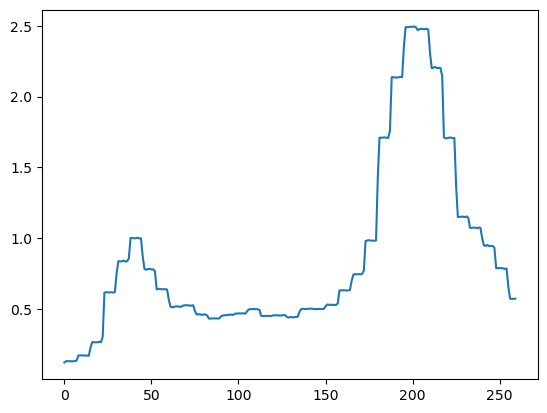

In [4]:
plt.plot(avg_rho[:,17])

In [3]:
import numpy as np
N=40
opt = 'milp_ol'
array_data = np.load('data_optimal_reduced//data_reduced_%s_N%.2d_%.3d.npy' %(opt, N, 0), allow_pickle=True)
for job_idx in range(1,25):
    tmp_vector = np.load('data_optimal_reduced//data_reduced_%s_N%.2d_%.3d.npy' %(opt,N, job_idx), allow_pickle=True)
    array_data = np.concatenate((array_data, tmp_vector))
# minlp_info_compressed = minlp_info_compressed[:120000, :]
np.save('data_optimal_reduced//data_reduced_%s_N%.2d_condensed.npy' %(opt,N), array_data, allow_pickle=True)

In [3]:
import numpy as np

opt_data = 'milp_ol'
opt_label = 'classification'

str_data = 'data_optimal_reduced//data_reduced_%s_N%d_%.3d.npy' %(opt_data, N, 0) # for testing
array_data = np.load(str_data, allow_pickle=True)
dict_state_list = array_data[0]
dict_output_list = array_data[1]

state_n = dict_state_list['state_n']
state_depot = dict_state_list['state_depot']
idx_cntr = dict_state_list['idx_cntr']
state_rho_down= dict_state_list['state_rho_down']
state_rho_mean= dict_state_list['state_rho_mean']
state_l_0= dict_state_list['state_l_0']
state_l_1= dict_state_list['state_l_1']
state_l_2= dict_state_list['state_l_2']
if opt_label=='classification':
        stacked_list_actions = dict_output_list['list_actions']
elif opt_label=='regression':
        stacked_list_actions = dict_output_list['delta']
for i in range(1,25):
    str_data = 'data_optimal_reduced//data_reduced_%s_N%d_%.3d.npy' %(opt_data, N, i) # for testing
    array_data = np.load(str_data, allow_pickle=True)
    dict_state_list = array_data[0]
    dict_output_list = array_data[1]
    
    state_n = np.concatenate((state_n, dict_state_list['state_n']))
    state_depot = np.concatenate((state_depot, dict_state_list['state_depot']))
    idx_cntr = np.concatenate((idx_cntr, dict_state_list['idx_cntr']))
    state_rho_down= np.concatenate((state_rho_down, dict_state_list['state_rho_down']))
    state_rho_mean= np.concatenate((state_rho_mean, dict_state_list['state_rho_mean']))
    state_l_0= np.concatenate((state_l_0, dict_state_list['state_l_0']))
    state_l_1= np.concatenate((state_l_1, dict_state_list['state_l_1']))
    state_l_2= np.concatenate((state_l_2, dict_state_list['state_l_2']))
    
    if opt_label=='classification':
        tmp = dict_output_list['list_actions']
    elif opt_label=='regression':
        tmp = dict_output_list['delta']    
    stacked_list_actions = np.concatenate((stacked_list_actions, tmp))

In [9]:
state_rho_mean.shape, state_l_0.shape, state_n.shape

((4827, 93), (4827, 93), (109364, 93))

In [6]:
state_rho_mean= dict_state_list['state_rho_mean']
state_l_0= dict_state_list['state_l_0']
stacked_states = np.concatenate((state_n, state_depot, idx_cntr, state_rho_mean, state_l_0), axis=1)

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 109364 and the array at index 3 has size 4827

In [2]:
array_data = np.load('data_optimal_reduced//data_reduced_%s_N%.2d_%.3d.npy' %(opt, N, 0), allow_pickle=True)
dict_state_list = array_data[0]
dict_output_list = array_data[1]

dict_state_list

NameError: name 'np' is not defined

In [14]:
opt = 'milp_cl'
array_data = np.load('data_optimal//data_%s_N%.2d_999.npy' %(opt, N), allow_pickle=True)

In [15]:
opt_data = 'milp_ol'
threshold_counts = 50
N = 40
opt_state=1
opt_label='classification'
testing=True

from rail_data_preprocess_original import get_preprocessed_data
from rail_data_preprocess_reduced import get_preprocessed_data_reduced

dict_data = get_preprocessed_data_reduced(opt_data, threshold_counts, N, opt_state, opt_label, testing)

stacked_states_val_tensor = dict_data['stacked_states_val_tensor']
stacked_states_val_tensor.shape

num_actions = 210
number of training points (before reduction): 87492
number of validation points (before reduction): 10936
number of test points (before reduction): 10936
number of training points (after reduction): 84560
number of validation points (after reduction): 10567
number of test points (after reduction): 10591
cntr_outlier_train: 2932	 cntr_outlier_val: 369 cntr_outlier_test: 345
data-processing finished


torch.Size([10567, 283])

In [2]:
N_control = dict_data['N_control']
stacked_actions_reduced_val = dict_data['stacked_actions_reduced_val']
list_masks = dict_data['list_masks']
stacked_states_val_tensor = dict_data['stacked_states_val_tensor']
input_size = dict_data['input_size']
total_action_set = dict_data['total_action_set']

In [10]:
batch_size = 32
device='cpu'
import torch
import numpy as np

stacked_actions_reduced_train = dict_data['stacked_actions_reduced_train']
stacked_actions_reduced_val = dict_data['stacked_actions_reduced_val']
stacked_states_train_tensor = dict_data['stacked_states_train_tensor']
stacked_states_val_tensor = dict_data['stacked_states_val_tensor']
batch = np.random.choice(stacked_states_train_tensor.shape[0], batch_size, replace=False)

from rail_training_reduced import build_pad_batch_states_tensor

b = torch.zeros(batch_size, N_control-1, input_size)
state_batch_train = build_pad_batch_states_tensor(stacked_states_train_tensor[batch].unsqueeze(dim=1), batch_size, input_size, N_control).to(device)

In [9]:
b = torch.zeros(batch_size, N_control-1, input_size)
stacked_states_train_tensor[batch].shape, b.shape

(torch.Size([32, 748]), torch.Size([32, 37, 748]))

In [28]:
m=238
n=32

4*(m*n+n**2+n) + n*200

41088